# OU AISI Steel Column Design Spreadsheet Calculations

## Inputs/Outputs


Inputs:

- Pile section type, number of piles, number of measurements, flange/web
thicknesses, length, material properties

Outputs:

- Individual and total pile capacitites, section loss, sensitivity tables
and charts

## Key Sheets and Roles

- `Summary`: Main user interface for inputs and results.
- `Intermediate Calcs`: Detailed calculations for each pile.
- `Sensitivity (kf & L), Sensitivity (tf & tw), Sensitivity (Individual),  
Sensitivity (All Flanges)`: Sensitivity analysis tables and charts.
- `Source Data`: HP section properties.
- `Sample Data`: Example measurement inputs.

Results using sample data (13 piles/pier, 4 measurements/element) and a  
column length of 8',

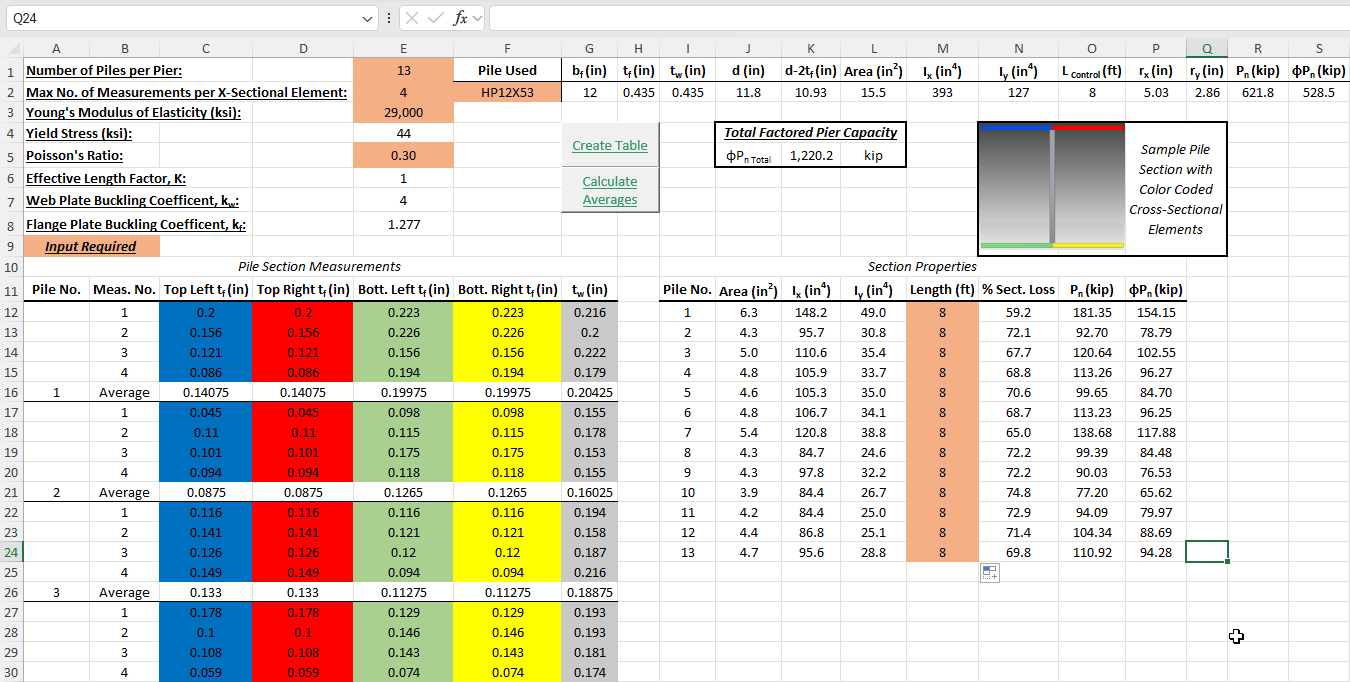

In [1]:
# Load the excel tables into python
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

In [2]:
sens_kf = pd.read_excel(r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\Projects\_Pier Columns\ODOT - Pile Capacity Sensitivity.xlsm", sheet_name="Sensitivity (kf & L)")
sens_tf = pd.read_excel(r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\Projects\_Pier Columns\ODOT - Pile Capacity Sensitivity.xlsm", sheet_name="Sensitivity (tf & tw)")
sens_ind = pd.read_excel(r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\Projects\_Pier Columns\ODOT - Pile Capacity Sensitivity.xlsm", sheet_name="Sensitivity (Individual)")
sens_all = pd.read_excel(r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\Projects\_Pier Columns\ODOT - Pile Capacity Sensitivity.xlsm", sheet_name="Sensitivity (All Flanges)")
summary_df = pd.read_excel(r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\Projects\_Pier Columns\ODOT - Pile Capacity Sensitivity.xlsm", sheet_name="Summary")
int_calcs = pd.read_excel(r"C:\Users\dparks1\OneDrive - State of Ohio\Documents\Projects\_Pier Columns\ODOT - Pile Capacity Sensitivity.xlsm", sheet_name="Intermediate Calcs")

# Source Data doesn't need pulled forward, it's the modern AISC Steel database (not sure on version)
# Same with sample data, will be entered later, the above tables probably won't all be used either

## Rebuilding Core Calculations

- Need to Calculate Area ($A$), $I_x$, $I_y$, $r_x$, $r_y$, critical stress $F_{cr}$, Nominal  
Capacity $P_n$, factored capacity $\phi P_n$
- Recreate the logic from the calculate averages macro to compute average thicknesses per pile.
- Build out the Capacity Table

In [59]:
# --- USER INPUT SECTION ---

# Number of piles per pier (integer)
number_of_piles = 13

# Maximum number of measurements per cross-sectional element (integer)
max_measurements_per_element = 4

# Young's Modulus of Elasticity in ksi (float)
youngs_modulus = 29000.0

# Yield Stress in ksi (float)
yield_stress = 44.0

# Poisson's Ratio (float, typically between 0.25 and 0.35 for steel)
poissons_ratio = 0.3

# Effective Length Factor, K (float, typically 1.0)
effective_length_factor = 1.0

# Web Plate Buckling Coefficient, kw (float, recommended 4.0)
k_w = 4.0

# Flange Plate Buckling Coefficient, kf:
# - Classical value for plate supported on one edge, free on other: k = 0.425 (Timoshenko)
# - The reference Excel sheet uses kf = 1.277 (see AISC Design Guide 3 or specific project ref)
# - 1.277 may apply when the flange is treated as simply supported on both edges;
#   verify against project-specific standards before changing.
k_f = 1.277  # Matches reference Excel sheet; change to 0.425 if using classical unstiffened plate formula
K = 1

# Pile section used (string, must match one of the standard HP sections)
pile_used = "HP12X53"

In [60]:
# Civilpy already has steel sections
from civilpy.structural.steel import HP

In [61]:
hp12x53 = HP(pile_used)

In [62]:
hp12x53.area

<Quantity(15.5, 'inch ** 2')>

Section loss table

In [63]:
class Pier:
    def __init__(self, pier_id: int, pile_count: int):
        self.id = pier_id
        self.number_of_piles = pile_count

    def __repr__(self):
        return f"<Pier #{self.id} with {self.number_of_piles} piles>"

In [64]:
class Pile:
    def __init__(self, pier: Pier, pile_number: int, section: str, insp_points: int,
                 length: float, youngs_modulus=29_000, yield_stress=44, poissons_ratio=0.3,
                 kf=1.277, kw=4.0,
                 K=1, web_plate_coeff=4, flange_plate_coeff=1.277):
        self.pier = pier
        self.pile_number = pile_number
        self.section = HP(section)  # //TODO - Probably should get switched to historical shapes
        self.insp_points = insp_points
        self.length = length
        self.youngs_modulus = youngs_modulus
        self.yield_stress = yield_stress
        self.poissons_ratio = poissons_ratio
        self.kf = kf
        self.kw = kw
        self.K = K
        self.web_plate_coeff = web_plate_coeff
        self.flange_plate_coeff = flange_plate_coeff

        # Each attribute is a dictionary: {measurement_number: thickness_value}
        self.top_left_tf = {i: None for i in range(1, insp_points + 1)}
        self.top_right_tf = {i: None for i in range(1, insp_points + 1)}
        self.bot_left_bf = {i: None for i in range(1, insp_points + 1)}
        self.bot_right_bf = {i: None for i in range(1, insp_points + 1)}
        self.web_tw = {i: None for i in range(1, insp_points + 1)}

        self.tl_avg = None
        self.tr_avg = None
        self.bl_avg = None
        self.br_avg = None
        self.tw_avg = None

    def get_section_averages(self):
        self.tl_avg = sum(self.top_left_tf.values()) / len(self.top_left_tf.values())
        self.tr_avg = sum(self.top_right_tf.values()) / len(self.top_right_tf.values())
        self.bl_avg = sum(self.bot_left_bf.values()) / len(self.bot_left_bf.values())
        self.br_avg = sum(self.bot_right_bf.values()) / len(self.bot_right_bf.values())
        self.tw_avg = sum(self.web_tw.values()) / len(self.web_tw.values())

    def get_effective_area(self):
        self.section.d2tf = self.section.depth.magnitude - 2 * self.section.flange_thickness.magnitude
        self.eff_area = sum([
            self.tl_avg * self.section.flange_width.magnitude / 2,
            self.tr_avg * self.section.flange_width.magnitude / 2,
            self.bl_avg * self.section.flange_width.magnitude / 2,
            self.br_avg * self.section.flange_width.magnitude / 2,
            self.tw_avg * self.section.d2tf
        ])

        self.section_loss = float((1 - self.eff_area / self.section.area.magnitude) * 100)

    def get_strong_moment_of_inertia(self):
        """
        Estimate the moment of inertia (Ix) of the pile cross-section using
        rectangular approximations and the parallel axis theorem.
        """
        # Ensure averages are calculated
        if None in (self.tl_avg, self.tr_avg, self.bl_avg, self.br_avg, self.tw_avg):
            raise ValueError("Section averages must be calculated before computing moment of inertia.")

        bf_half = self.section.flange_width.magnitude / 2  # Half flange width
        k2 = self.section.depth.magnitude - 2 * self.section.flange_thickness.magnitude

        def I_flange(tf):
            # Ix for a rectangle + parallel axis term
            return (1 / 12) * bf_half * tf ** 3 + bf_half * tf * ((k2 + tf) / 2) ** 2

        # Sum contributions from all four flanges
        I_flange_total = (
                I_flange(self.tl_avg) +
                I_flange(self.tr_avg) +
                I_flange(self.bl_avg) +
                I_flange(self.br_avg)
        )

        # Web contribution (centroid assumed at neutral axis)
        I_web = (1 / 12) * self.tw_avg * k2 ** 3

        self.eff_I_x = I_flange_total + I_web

        return I_flange_total + I_web

    def get_weak_moment_of_inertia(self):
        """
        Estimate the moment of inertia (Iy) of the pile cross-section using
        rectangular approximations and the parallel axis theorem.
        """
        if None in (self.tl_avg, self.tr_avg, self.bl_avg, self.br_avg, self.tw_avg):
            raise ValueError("Section averages must be calculated before computing moment of inertia.")

        bf_half = self.section.flange_width.magnitude / 2  # Half flange width
        k2 = self.section.depth.magnitude - 2 * self.section.flange_thickness.magnitude  # Web height

        def I_flange_y(tf):
            # Iy for a vertical rectangle (tf wide, bf_half tall) + parallel axis
            return (1 / 12) * tf * bf_half ** 3 + tf * bf_half * (bf_half / 2) ** 2

        I_flange_total_y = (
                I_flange_y(self.tl_avg) +
                I_flange_y(self.tr_avg) +
                I_flange_y(self.bl_avg) +
                I_flange_y(self.br_avg)
        )

        # Web contribution (no offset from centroid)
        I_web_y = (1 / 12) * self.tw_avg ** 3 * k2

        self.eff_I_y = I_flange_total_y + I_web_y

        return I_flange_total_y + I_web_y

    def get_radius_gyration(self):
        self.eff_r_x = math.sqrt(self.eff_I_x / self.eff_area)
        self.eff_r_y = math.sqrt(self.eff_I_y / self.eff_area)

    def get_P_n(self):
        analysis_points = {0: self.tl_avg, 1: self.tr_avg, 2: self.bl_avg, 3: self.br_avg, 4: self.tw_avg}
        p_ns = {}

        for i in range(0, 5, 1):
            thickness = analysis_points[i]

            f_crl = self.kf * (math.pi ** 2 * self.youngs_modulus) / (12 * (1 - self.poissons_ratio ** 2) * (
                        (self.section.flange_width.magnitude / 2) / thickness) ** 2)
            f_cre = (math.pi ** 2 * self.youngs_modulus) / (
                        (self.K * self.length * 12 / min(self.eff_r_x, self.eff_r_y)) ** 2)
            lambda_c = math.sqrt(self.yield_stress / f_cre)

            if lambda_c <= 1.5:
                F_n = 0.658 ** lambda_c ** 2 * self.yield_stress
            else:
                F_n = (0.877 / lambda_c ** 2) * self.yield_stress

            lambda_var = math.sqrt(F_n / f_crl)

            if lambda_var <= 0.673:
                rho = 1
                b_e = self.section.flange_width / 2
            else:
                rho = (1 - 0.22 / lambda_var) / lambda_var
                b_e = self.section.flange_width.magnitude / 2 * rho

            A_e = b_e * self.tl_avg
            P_n = A_e * F_n

            p_ns[i] = P_n

            self.p_ns = p_ns
        return p_ns

    def __repr__(self):
        return f"<PileSection #{self.pile_number} with {self.insp_points} measurements>"

### How to use Python Classes

In [65]:
# Defining a Pier
ex_pier = Pier(pier_id = 1, pile_count = 13)

In [66]:
ex_pier

<Pier #1 with 13 piles>

In [68]:
pile_1 = Pile(pier=ex_pier, pile_number=1, section='HP12X53', kw=k_w, 
                     kf=k_f, insp_points=4, length=8)

In [69]:
pile_1.web_tw

{1: None, 2: None, 3: None, 4: None}

In [70]:
pile_1.web_tw[1] = 0.216  # Replaced the generated None values w/ field values
pile_1.web_tw[2] = 0.2
pile_1.web_tw[3] = 0.222
pile_1.web_tw[4] = 0.179

In [71]:
pile_1.web_tw

{1: 0.216, 2: 0.2, 3: 0.222, 4: 0.179}

Do this for all measurements on all sections, will have to be updated for  
how many columns/piers/piles you have.

In [72]:
pile_1.top_left_tf[1] = 0.2
pile_1.top_left_tf[2] = 0.156
pile_1.top_left_tf[3] = 0.121
pile_1.top_left_tf[4] = 0.086

In [73]:
pile_1.top_right_tf[1] = 0.2
pile_1.top_right_tf[2] = 0.156
pile_1.top_right_tf[3] = 0.121
pile_1.top_right_tf[4] = 0.086

In [74]:
pile_1.bot_left_bf[1] = 0.223
pile_1.bot_left_bf[2] = 0.226
pile_1.bot_left_bf[3] = 0.156
pile_1.bot_left_bf[4] = 0.194

In [75]:
pile_1.bot_right_bf[1] = 0.223
pile_1.bot_right_bf[2] = 0.226
pile_1.bot_right_bf[3] = 0.156
pile_1.bot_right_bf[4] = 0.194

calculate the average section loss for each of the 5 components,

In [76]:
pile_1.get_section_averages()

In [77]:
# options are tw_avg (web), br_avg, bl_avg (Bottom L/R), or tl/tr_avg (Top)
pile_1.tw_avg

0.20425

With the averages, calculate the new section properties,

- `Area` (A)  
- `Moment of Inertia` (Ix, Iy)  
- `Radius of Gyration` (rx, ry)  
- `Section Loss %` (compared to the original HP section)  
- `Nominal Capacity` (Pn)  
- `Factored Capacity` (φPn)

these are done with some really cool excel formulas...

```excel
=IF(I12<>"",INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),3)*$G$2/2+INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),4)*$G$2/2+INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),5)*$G$2/2+INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),6)*$G$2/2+INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),7)*$K$2,"")
```

reformatted,

```excel
=IF(I12<>"",
    INDEX($A$12:$G$1006, MATCH(I12, $A$12:$A$1006, 0), 3)*$G$2/2 +
    INDEX($A$12:$G$1006, MATCH(I12, $A$12:$A$1006, 0), 4)*$G$2/2 +
    INDEX($A$12:$G$1006, MATCH(I12, $A$12:$A$1006, 0), 5)*$G$2/2 +
    INDEX($A$12:$G$1006, MATCH(I12, $A$12:$A$1006, 0), 6)*$G$2/2 +
    INDEX($A$12:$G$1006, MATCH(I12, $A$12:$A$1006, 0), 7)*$K$2,
"")

```

Match I12 is using the pile number (1 selected here) and looking that up in  
summary A12:G1006, basically the section loss, then it multiples it by the  
original bottom flange width / 2 and adds them together. Except for the web  
which uses $d$-2$t_f$.

In [78]:
pile_1.get_effective_area()
pile_1.eff_area

6.3184525

$I_x$

```excel
=IF(I12<>"",((1/12)*($G$2/2)*(INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),3)^3)+($G$2/2*INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),3))*(($K$2+INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),3))/2)^2)+((1/12)*($G$2/2)*(INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),4)^3)+($G$2/2*INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),4))*(($K$2+INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),4))/2)^2)+((1/12)*($G$2/2)*(INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),5)^3)+($G$2/2*INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),5))*(($K$2+INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),5))/2)^2)+((1/12)*($G$2/2)*(INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),6)^3)+($G$2/2*INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),6))*(($K$2+INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),6))/2)^2)+((1/12)*(INDEX($A$12:$G$1006,MATCH(I12,$A$12:$A$1006,0),7))*($K$2^3)),"")
```

Which appears to just be doing the $\frac{1}{12} b * h^3 $ calculation


In [79]:
pile_1.get_strong_moment_of_inertia()

148.21722785639588

$I_y$

In [80]:
pile_1.get_weak_moment_of_inertia()

49.03976113274361

$\%\ Section\ Loss$

Just compares original section's area to total area with loss,

In [81]:
pile_1.section_loss

59.23579032258064

$ P_n $

Sums 5 cells from the `Intermediate Calcs` sheet, each of those relies on 9  
values,

$F_{cr\ell}$: 

Formula,

$$ = k \frac{\pi^2 * E}{12(1-\mu^2)}\big( \frac{t}{w} \big) ^2 \tag{AISI Appendix A Eq. 1.1-4}$$

Excel: `=IF($A3<>"",(kf*PI()^2*E)/(12*(1-v^2)*((Summary!$G$2/2)/(INDEX(Summary!$A$12:$G$1000,MATCH($A3,Summary!$A$12:$A$1000,0),3)))^2),"")`  

Python:

In [82]:
import math

f_crl = pile_1.kf * (math.pi**2 * pile_1.youngs_modulus) / (
        12 * (1 - pile_1.poissons_ratio**2) * (
            (pile_1.section.flange_width.magnitude / 2) / 
            pile_1.tl_avg)**2  
    # Note `tl_avg` changes for each flange
    )

# Classical elastic plate buckling stress (Timoshenko & Gere, Theory of Elastic Stability):
# f_crl = kf * pi^2 * E / (12 * (1 - v^2) * (b/t)^2)
# where b = half-flange width, t = tl_avg (average measured flange thickness)
f_crl

6.129969889293441

$F_{cre}$: 

Formula,

$$ = \frac{\pi^2  E}{(K L / r)^2} \tag{AISI Chapter E Eq. E2.1-1} $$

Where:

$ E $ = Modulus of elasticity of steel  
$ K $ = Effective length factor determined in accordance with Chapter C  
$ L $ = Laterally unbraced length of member  
$ r $ = Radius of gyration of full unreduced cross-section about axis of buckling  

`# //TODO - AISI says unreduced cross-section, the excel formula is reducing the x-section`

Excel: `=IF($A3<>"",(PI()^2*E)/(K*INDEX(Summary!$I$12:$M$1000,MATCH($A3,Summary!$I$12:$I$1000,0),5)*12/MIN($E3,$F3))^2,"")`  

Python:

In [83]:
pile_1.get_radius_gyration()

f_cre = (math.pi**2 * pile_1.youngs_modulus) / (
    (pile_1.K * pile_1.length * 12 / min(pile_1.eff_r_x, pile_1.eff_r_y)
    )**2)

In [84]:
f_cre

241.0420977992238

$Lambda_c$: 

$$ \lambda_c = \sqrt{\frac{F_y}{f_{cre}}} \tag{Eq. E2-4} $$

Excel: `=IF($A3<>"",SQRT(Fy/H3),"")`  




In [85]:
lambda_c = math.sqrt(pile_1.yield_stress / f_cre)
lambda_c

0.4272478530720863

$F_n$: 

$$F_n = \begin{cases} \left(0.658^{\lambda_c^2}\right) F_y & \text{For } \lambda_c \le 1.5 \\ \left(\frac{0.877}{\lambda_c^2}\right) F_y & \text{For } \lambda_c > 1.5 \end{cases} \tag{AISI E2-2/3}$$

Excel: `=IF($A3<>"",IF(I3<=1.5,(0.658^(I3^2))*Fy,(0.877/I3^2)*Fy),"")`  




In [86]:
if lambda_c <= 1.5:
    F_n = 0.658 ** lambda_c ** 2 * pile_1.yield_stress
else:
    F_n = (0.877 / lambda_c ** 2) * pile_1.yield_stress

F_n

40.76350308191337

$\lambda$: 

$$ \lambda = \sqrt{F_n / F_{cr\ell}} \tag{AISI Appendix A Eq. 1.1-3} $$ 

Excel: `=IF($A3<>"",SQRT(J3/G3),"")`  

In [87]:
lambda_var = math.sqrt(F_n / f_crl)
lambda_var

2.5787341923786333

$\rho$: 


$$\rho = \begin{cases} 1 & \text{For } \lambda \leq 0.673 \\ 
(1-0.22/\lambda ) / \lambda & \text{For } \lambda > 0.673 \end{cases} \tag{AISI Appendix A Eq. 1.1-2}$$

Excel: `=IF($A3<>"",IF((1-(0.22/K3))*(1/K3)<1,(1-(0.22/K3))*(1/K3),1),"")`  

In [88]:
if lambda_var <= 0.673:
    rho = 1
else:
    rho = (1 - 0.22 / lambda_var) / lambda_var

rho

0.35470380322988737

$b_e$: 

$$ b = \rho w \tag{AISI Appendix A Eq. 1.1-1} $$

Seems like excel is mixing in components from Eq. 1.1-7 (the lambda check)

Excel: `=IF($A3<>"",IF(K3<=0.673,Summary!$G$2/2,Summary!$G$2/2*L3),"")`  

In [89]:
if lambda_var <= 0.673:
    b_e = pile_1.section.flange_width / 2
else:
    b_e = pile_1.section.flange_width / 2 * rho

# //TODO - combine with above when compiling

b_e

<Quantity(2.12822282, 'inch')>

$A_e$: 

Excel: `=IF($A3<>"",M3*INDEX(Summary!$A$12:$G$1000,MATCH($A3,Summary!$A$12:$A$1000,0),3),"")`  

In [90]:
A_e = b_e * pile_1.tl_avg
A_e

<Quantity(0.299547362, 'inch')>

$P_n$: 

$$ P_{n \ell} = A_e F_n \leq P_{ne} \tag{AISI Eq. E3.1-1} $$

Excel: `=IF($A3<>"",N3*J3,"")`  

In [91]:
P_n = A_e * F_n
P_n

<Quantity(12.2105998, 'inch')>

$ \phi P_n $

In [92]:
factored_P_n = 0.85 * P_n
factored_P_n

<Quantity(10.3790098, 'inch')>

The above needs done for each flange...

In [93]:
analysis_points = {0: pile_1.tl_avg, 1: pile_1.tr_avg, 2: pile_1.bl_avg, 3: pile_1.br_avg, 4: pile_1.tw_avg}

def get_P_n():
    p_ns = {}
    
    for i in range(0, 5, 1):
        thickness = analysis_points[i]

        f_crl = pile_1.kf * (math.pi**2 * pile_1.youngs_modulus) / (12 * (1 - pile_1.poissons_ratio**2) * ((pile_1.section.flange_width.magnitude / 2) / thickness)**2)
        f_cre = (math.pi**2 * pile_1.youngs_modulus) / ((pile_1.K * pile_1.length * 12 / min(pile_1.eff_r_x, pile_1.eff_r_y))**2)
        lambda_c = math.sqrt(pile_1.yield_stress / f_cre)
    
        if lambda_c <= 1.5:
            F_n = 0.658 ** lambda_c ** 2 * pile_1.yield_stress
        else:
            F_n = (0.877 / lambda_c ** 2) * pile_1.yield_stress
    
        lambda_var = math.sqrt(F_n / f_crl)
    
        if lambda_var <= 0.673:
            rho = 1
            b_e = pile_1.section.flange_width / 2
        else:
            rho = (1 - 0.22 / lambda_var) / lambda_var
            b_e = pile_1.section.flange_width.magnitude / 2 * rho
    
        A_e = b_e * pile_1.tl_avg
        P_n = A_e * F_n

        p_ns[i] = P_n
    return p_ns

In [94]:
get_P_n()

{0: 12.210599807040019,
 1: 12.210599807040019,
 2: 16.65155418099008,
 3: 16.65155418099008,
 4: 16.973843591760534}

In [95]:
# pile_1.get_P_n()

## Sensitivity Analysis

- **$k_f$ & $L$ Sensitivity**
    - Loop over ranges of $k_f$ & $L$, compute capacities, and store results in  
a matrix
- **$t_f$ & $t_w$ Sensitivity**
    - Vary flange and web thicknesses, compute capacities, and store in a
2D grid.
- **Individual Sensitivities**
    - Vary one parameter at a time (either $t_f$ or $t_w$) and track capacity
changes.
- **All Flanges Sensitivity**
    - Apply the same tf to all flanges and analyze the impact.
 

Not going to try to recreate these all in python, here's the basic premise;

## Visualization

Plot Sensitivity Charts  
Use matplotlib to replicate Excel charts:  
XY scatter plots  
Polynomial trendlines  
Annotated equations and R² values  

## Validation and Testing

Cross-Check Results

Compare outputs from your notebook with the Excel workbook to ensure accuracy.
Add Error Handling

Validate inputs and handle edge cases (e.g., missing or invalid data).

## Enhancements

Interactive Widgets

Use ipywidgets to create dropdowns and sliders for user inputs.
Export to Excel or PDF

Allow users to export results and charts for reporting.